# Reproducibility notes

Run this notebook from top to bottom. All paths are relative to the project folder, random behaviour is controlled by `RANDOM_SEED`, and generated files are written to `outputs/`. See `README.md` for the required folder structure and complete run instructions.


# COMP5310 Assignment 1
## 1. Comparative Analysis


### Setup and airline dataset

The following cell imports all dependencies once, fixes the project-wide random seed, creates the output folder, and loads data through one documented relative-path convention.


In [4]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

RANDOM_SEED = 5310
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.titleweight": "bold"})

def load_csv(filename):
    # Load a required CSV and raise an actionable error if it is absent.
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}. "
            "See README.md for the expected project structure."
        )
    return pd.read_csv(path)

print("pandas version:", pd.__version__)
print("Random seed:", RANDOM_SEED)




pandas version: 3.0.3
Random seed: 5310


In [5]:
hotel_bookings= pd.read_csv('data/hotel_bookings.csv')

In [6]:
display(hotel_bookings.describe(include='all'))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119987,119987.000000,119987.000000,119987.000000,119987,119987.000000,119987.000000,119987.000000,119987.000000,119987.000000,119805.000000,119987.000000,119849,119359,119858,119823,119987.000000,119987.000000,119987.000000,119987,119987,119987.000000,119987,103446.000000,6825.000000,119987.000000,119833,119987.000000,119987.000000,119987.000000,119987,119987
unique,4,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,177,14,9,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,8,NaN,NaN,NaN,6,1686
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79570,NaN,NaN,NaN,13954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92498,48778,56673,98049,NaN,NaN,NaN,86442,74418,NaN,105162,NaN,NaN,NaN,89824,NaN,NaN,NaN,75425,1443
mean,NaN,0.370440,106.105478,2016.156450,NaN,27.166810,15.799395,0.927634,2.499912,1.856284,0.103927,0.007959,NaN,NaN,NaN,NaN,0.031928,0.086968,0.136906,NaN,NaN,0.221074,NaN,86.741537,189.475604,2.319201,NaN,102.801864,0.062482,0.571195,NaN,NaN
std,NaN,0.482925,114.786587,0.707567,NaN,13.605147,8.782317,0.998560,1.907699,0.578709,0.398603,0.097448,NaN,NaN,NaN,NaN,0.175810,0.842424,1.495620,NaN,NaN,0.652046,NaN,110.810466,131.735152,17.580735,NaN,55.962944,0.245211,0.792577,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.360000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,14.000000,179.000000,0.000000,NaN,95.000000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,161.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


## 2. Stakeholder Problem and Success Criteria

### 2.1 Primary stakeholder and decision

The primary stakeholder is the hotel’s revenue or reservations manager. This stakeholder is responsible for managing room availability, cancellation risk, occupancy, pricing, and the financial consequences of rooms becoming vacant shortly before arrival.

The manager’s concrete decision is whether a future booking should be treated as having a high risk of cancellation. For bookings identified as high risk, the manager may consider operational responses such as sending confirmation reminders, requesting deposits, offering flexible rebooking options, reviewing the booking manually, or adjusting overbooking limits. The decision is therefore not simply whether a guest “will cancel,” but whether the estimated cancellation risk is sufficiently high to justify an intervention.

This decision matters because hotel rooms are perishable inventory. If a booking is cancelled close to the arrival date and the room cannot be resold, the revenue opportunity for that night is permanently lost. At the same time, treating too many reliable customers as high risk may create inconvenience, reduce customer satisfaction, and damage the hotel’s reputation. The hotel therefore needs an evidence-based method for distinguishing genuinely risky bookings from those likely to be honoured.

### 2.2 Focused research and business question

The broader business problem is that the hotel experiences a substantial number of booking cancellations but has limited resources for monitoring or contacting every customer. In the supplied dataset, 44,448 of 119,987 bookings were cancelled, corresponding to an overall cancellation rate of approximately 37.0%. This indicates that cancellation is not a rare event and may have a meaningful effect on occupancy planning and revenue management.

A focused business question is:

> Using information available to the hotel before the guest’s scheduled arrival, which bookings are most likely to be cancelled, and how can these predictions support targeted cancellation-management decisions?

This question can be divided into two related analytical objectives:

1. **Explanatory objective:** Identify the booking and customer characteristics associated with higher cancellation rates.

2. **Predictive objective:** Estimate the probability that an individual future booking will be cancelled.

The intended target variable is `is_canceled`, which is binary: a value of 1 indicates that the booking was cancelled, while a value of 0 indicates that it was not cancelled. The unit of analysis is an individual hotel booking.

Potential predictors include lead time, hotel type, market segment, distribution channel, deposit type, customer type, previous cancellations, repeated-guest status, booking changes, average daily rate, required parking spaces, and the number of special requests. These variables may help the hotel identify patterns that are available before arrival and potentially actionable.

However, the analysis should exclude `reservation_status` and `reservation_status_date` from the predictor set. These fields record the eventual status of the reservation and when that status was recorded. Using them would reveal information about the outcome and create data leakage, producing unrealistically strong performance that would not be available when assessing a genuine future booking.

### 2.3 Intended practical outcome

The intended outcome is a model or decision framework that assigns each booking an estimated probability of cancellation. The hotel could then rank upcoming bookings by risk or place them into categories such as low, medium, and high risk.

For example, the hotel might intervene only when the predicted cancellation probability exceeds a selected threshold. The threshold should reflect the relative cost of different errors and the hotel’s operational capacity. If contacting a customer is inexpensive, the manager may accept more false alarms in exchange for identifying a larger proportion of cancellations. If the intervention involves a restrictive deposit requirement or overbooking decision, a higher threshold may be necessary.

The analysis should also identify the variables that contribute most strongly to cancellation risk. This would help the stakeholder understand whether cancellation is associated with factors such as long lead times, particular market segments, previous cancellation behaviour, deposit arrangements, or a lack of special requests. An interpretable result is important because managers need to understand and justify the actions taken in response to the model.

### 2.4 What a useful answer would look like

A useful answer should satisfy four criteria.

First, it should be **predictively reliable**. The model should be evaluated on bookings that were not used for model training. Because the dataset covers time-dependent hotel bookings, a chronological split may be more realistic than a completely random split: earlier bookings can be used for training and later bookings for testing. This better represents the real operational situation in which past data are used to predict future behaviour.

Second, the predictions should be **well calibrated**. If a group of bookings receives an estimated cancellation probability of 70%, approximately 70% of those bookings should actually be cancelled. Calibration is especially important when the hotel uses predicted probabilities to compare the cost of intervention with the expected cost of cancellation.

Third, the model should provide an **operationally useful balance between false positives and false negatives**. Relevant evaluation measures may include:

* Recall, measuring the proportion of actual cancellations correctly identified.
* Precision, measuring how many bookings flagged as high risk actually cancel.
* ROC-AUC or PR-AUC, measuring the model’s ability to distinguish higher-risk bookings from lower-risk bookings.
* A confusion matrix, showing the number of false positives and false negatives at a selected decision threshold.
* Calibration measures or plots, showing whether predicted probabilities correspond to observed cancellation rates.

Accuracy alone would be insufficient. Because approximately 63% of the bookings were not cancelled, a simple model that predicted “not cancelled” for every booking could achieve approximately 63% accuracy while failing to identify any cancellations.

Finally, the answer should be **interpretable and actionable**. It should show the most important risk factors, compare cancellation rates across meaningful segments, and explain what the hotel can reasonably do with the findings. A technically accurate model would still have limited value if its output could not be connected to a practical decision.

### 2.5 Cost of a misleading conclusion

A misleading result could create several types of operational and financial harm.

A **false negative** occurs when a booking is classified as low risk but is later cancelled. If the cancellation occurs close to arrival, the hotel may be unable to resell the room, resulting in lost revenue and lower occupancy. A large number of false negatives may also lead the manager to underestimate cancellation risk and maintain an insufficient overbooking allowance.

A **false positive** occurs when a reliable booking is incorrectly classified as high risk. This may lead to unnecessary reminder messages, deposit requirements, manual reviews, or aggressive overbooking. Customers may perceive these actions as inconvenient or unfair. In extreme cases, excessive overbooking based on unreliable predictions could leave the hotel without a room for a customer who arrives as planned, creating compensation expenses and reputational damage.

Misleading conclusions about individual risk factors can also produce poor policies. For example, a correlation between a market segment and cancellation does not necessarily mean that the segment itself causes cancellation. The relationship may be influenced by lead time, deposit type, season, or distribution channel. Applying restrictive conditions to an entire customer group without controlling for these factors could unfairly affect reliable customers.

For these reasons, model performance should be compared with a simple baseline, evaluated on unseen data, checked for leakage, and translated into estimated business costs. The final recommendation should not claim that the model can eliminate cancellations. Instead, it should show whether the model improves the hotel’s ability to prioritize limited interventions compared with treating all bookings in the same way.



# 3. Data Readiness Pipeline

## 3.1 Data Quality Audit

The selected Hotel Booking dataset is audited before cleaning to identify
missing values, duplicate records, incorrect data types, invalid values,
inconsistent categories, unusual ranges, and potential target leakage.
Cleaning decisions are made based on the stakeholder question and the
availability of variables at the intended decision time.

In [7]:
#Refered from https://www.youtube.com/watch?v=y1UNXarQwSY
# first re-checking for the missing values in our dataset
missing_values=hotel_bookings.isnull().sum
print("Missing Values : \n", missing_values())

Missing Values : 
 hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                             182
babies                                 0
meal                                 138
country                              628
market_segment                       129
distribution_channel                 164
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              165

In [8]:
#rechecking the duplicate values
duplicate_values=hotel_bookings.duplicated()
print("Duplicated Value:\n", duplicate_values.sum())



Duplicated Value:
 31328


In [9]:
hotel_bookings.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119987.000000,119987.000000,119987.000000,119987.000000,119987.000000,119987.000000,119987.000000,119987.000000,119805.000000,119987.000000,119987.000000,119987.000000,119987.000000,119987.000000,103446.000000,6825.000000,119987.000000,119987.000000,119987.000000,119987.000000
mean,0.370440,106.105478,2016.156450,27.166810,15.799395,0.927634,2.499912,1.856284,0.103927,0.007959,0.031928,0.086968,0.136906,0.221074,86.741537,189.475604,2.319201,102.801864,0.062482,0.571195
std,0.482925,114.786587,0.707567,13.605147,8.782317,0.998560,1.907699,0.578709,0.398603,0.097448,0.175810,0.842424,1.495620,0.652046,110.810466,131.735152,17.580735,55.962944,0.245211,0.792577
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.360000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,95.000000,0.000000,0.000000
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,1636.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:

print("Negative ADR:", (hotel_bookings["adr"] < 0).sum())
print("Negative lead time:", (hotel_bookings["lead_time"] < 0).sum())
print("Negative adults:", (hotel_bookings["adults"] < 0).sum())
print("Negative children:", (hotel_bookings["children"] < 0).sum())
print("Negative babies:", (hotel_bookings["babies"] < 0).sum())

Negative ADR: 1
Negative lead time: 0
Negative adults: 0
Negative children: 0
Negative babies: 0


In [11]:
zero_guests = (
    (hotel_bookings["adults"] == 0) &
    (hotel_bookings["children"].fillna(0) == 0) &
    (hotel_bookings["babies"] == 0)
)

print("Bookings with zero guests:", zero_guests.sum())

Bookings with zero guests: 180


In [12]:
hotel_bookings_cleaned =hotel_bookings.dropna()

| Variable               |   Missing | Initial decision |
| ---------------------- | --------: | ---------------- |
| `agent`                |    16,541 | **Investigate**  |
| `company`              | very high | **Investigate**  |
| `country`              |       628 | **Investigate**  |
| `distribution_channel` |       164 | **Investigate**  |
| `market_segment`       |       129 | **Investigate**  |
| `meal`                 |       138 | **Investigate**  |
| `children`             |       182 | **Investigate**  |


In [13]:
#This helps us to decide the association the data that is missing with the cancelled column to know the importance of it.
missing_cols = hotel_bookings.columns[
    hotel_bookings.isna().any()
]

for col in missing_cols:
    print(f"\n--- {col} ---")
    print(hotel_bookings[col].isna().sum())
    print(hotel_bookings.loc[hotel_bookings[col].isna(), "is_canceled"].value_counts(normalize=True))


--- children ---
182
is_canceled
0    0.648352
1    0.351648
Name: proportion, dtype: float64

--- meal ---
138
is_canceled
0    0.586957
1    0.413043
Name: proportion, dtype: float64

--- country ---
628
is_canceled
0    0.802548
1    0.197452
Name: proportion, dtype: float64

--- market_segment ---
129
is_canceled
0    0.565891
1    0.434109
Name: proportion, dtype: float64

--- distribution_channel ---
164
is_canceled
0    0.585366
1    0.414634
Name: proportion, dtype: float64

--- agent ---
16541
is_canceled
0    0.75201
1    0.24799
Name: proportion, dtype: float64

--- company ---
113162
is_canceled
0    0.617813
1    0.382187
Name: proportion, dtype: float64

--- customer_type ---
154
is_canceled
0    0.61039
1    0.38961
Name: proportion, dtype: float64


In [14]:
# creating a working dataset so we can proccess without loosing orignial data
hotel_bookings_cleaned = hotel_bookings.copy()

In [15]:
for col in missing_cols:
    print(f"\n===== {col} =====")
    print(hotel_bookings.loc[hotel_bookings[col].isna(), 
                             [col, "is_canceled"]].head(10))


===== children =====
      children  is_canceled
86         NaN            1
1016       NaN            0
1204       NaN            1
2155       NaN            0
2559       NaN            1
3138       NaN            1
3822       NaN            0
3909       NaN            1
4336       NaN            0
5781       NaN            0

===== meal =====
     meal  is_canceled
206   NaN            0
3046  NaN            1
4492  NaN            1
5128  NaN            0
5320  NaN            0
5688  NaN            1
6365  NaN            1
6607  NaN            0
6828  NaN            0
7202  NaN            0

===== country =====
     country  is_canceled
10       NaN            0
121      NaN            0
351      NaN            0
592      NaN            0
679      NaN            0
808      NaN            0
1084     NaN            0
1169     NaN            0
1237     NaN            1
1253     NaN            1

===== market_segment =====
     market_segment  is_canceled
6               NaN            

In [16]:
for col in missing_cols:
    print(f"\n===== {col} =====")
    print("Missing:", hotel_bookings[col].isna().sum())
    print("Missing %:", round(hotel_bookings[col].isna().mean() * 100, 2))
    print("Data type:", hotel_bookings[col].dtype)
    
    display(
        hotel_bookings.loc[
            hotel_bookings[col].isna(),
            [col, "is_canceled"]
        ].head(10)
    )


===== children =====
Missing: 182
Missing %: 0.15
Data type: float64


,children,is_canceled
86,NaN,1
1016,NaN,0
1204,NaN,1
2155,NaN,0
2559,NaN,1
3138,NaN,1
3822,NaN,0
3909,NaN,1
4336,NaN,0
5781,NaN,0



===== meal =====
Missing: 138
Missing %: 0.12
Data type: str


,meal,is_canceled
206,NaN,0
3046,NaN,1
4492,NaN,1
5128,NaN,0
5320,NaN,0
5688,NaN,1
6365,NaN,1
6607,NaN,0
6828,NaN,0
7202,NaN,0



===== country =====
Missing: 628
Missing %: 0.52
Data type: str


...

,agent,is_canceled
10,NaN,0
18,NaN,1
47,NaN,0
48,NaN,1
57,NaN,0
64,NaN,0
69,NaN,1
70,NaN,1
79,NaN,0
81,NaN,1



===== company =====
Missing: 113162
Missing %: 94.31
Data type: float64


,company,is_canceled
0,NaN,1
1,NaN,0
2,NaN,0
3,NaN,1
4,NaN,0
5,NaN,0
6,NaN,1
7,NaN,1
8,NaN,0
9,NaN,0



===== customer_type =====
Missing: 154
Missing %: 0.13
Data type: str


,customer_type,is_canceled
369,NaN,1
709,NaN,1
1035,NaN,0
3743,NaN,1
4131,NaN,0
5299,NaN,1
5613,NaN,0
6674,NaN,0
8855,NaN,0
8866,NaN,0


In [17]:

# Missing-value treatment
hotel_bookings_cleaned["children"] = (
    hotel_bookings_cleaned["children"].fillna(0)
)

hotel_bookings_cleaned["meal"] = (
    hotel_bookings_cleaned["meal"].fillna("Undefined")
)

hotel_bookings_cleaned["country"] = (
    hotel_bookings_cleaned["country"].fillna("Unknown")
)

hotel_bookings_cleaned["market_segment"] = (
    hotel_bookings_cleaned["market_segment"].fillna("Unknown")
)

hotel_bookings_cleaned["distribution_channel"] = (
    hotel_bookings_cleaned["distribution_channel"].fillna("Unknown")
)

hotel_bookings_cleaned["customer_type"] = (
    hotel_bookings_cleaned["customer_type"].fillna("Unknown")
)

# company: remove because of extremely high missingness
hotel_bookings_cleaned = hotel_bookings_cleaned.drop(columns=["company"])

In [18]:
#verify cleaning
hotel_bookings_cleaned.isna().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              0
babies                                0
meal                                  0
country                               0
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             16541
days_in_waiting_list                  0


In [19]:
#understand agent data before cleaning
print(hotel_bookings_cleaned["agent"].value_counts(dropna=False).head(20))

agent
9.0      32075
NaN      16541
240.0    13986
1.0       7221
14.0      3649
7.0       3544
6.0       3300
250.0     2886
241.0     1726
28.0      1675
8.0       1519
3.0       1342
37.0      1230
19.0      1065
40.0      1042
314.0      932
21.0       877
229.0      790
242.0      778
83.0       702
Name: count, dtype: int64


In [20]:
print(hotel_bookings_cleaned["agent"].describe())


count    103446.000000
mean         86.741537
std         110.810466
min           1.000000
25%           9.000000
50%          14.000000
75%         229.000000
max         535.000000
Name: agent, dtype: float64


In [21]:
#agent missing column as the data cannot be converted 
hotel_bookings_cleaned["agent_missing"] = (
    hotel_bookings_cleaned["agent"].isna().astype(int)
)

### Duplicated Data 

In [22]:
display(
    hotel_bookings.loc[
        hotel_bookings.duplicated(keep=False)
    ].sort_values(
        hotel_bookings.columns.tolist()
    ).head(20)
)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
8552,City Hotel,0,0,2015,August,32,7,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
55138,City Hotel,0,0,2015,August,32,7,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
59486,City Hotel,0,0,2015,August,32,8,0,1,2,0.0,0,SC,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
99433,City Hotel,0,0,2015,August,32,8,0,1,2,0.0,0,SC,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
37020,City Hotel,0,0,2015,August,33,10,1,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
37275,City Hotel,0,0,2015,August,33,10,1,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
66784,City Hotel,0,0,2015,August,33,10,1,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
108702,City Hotel,0,0,2015,August,33,10,1,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
68442,City Hotel,0,0,2015,August,33,11,0,1,1,0.0,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
71548,City Hotel,0,0,2015,August,33,11,0,1,1,0.0,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12


In [23]:
duplicate_rows = hotel_bookings[
    hotel_bookings.duplicated(keep=False)
]

print(
    duplicate_rows.groupby(
        hotel_bookings.columns.tolist()
    )["is_canceled"].nunique().value_counts()
)

is_canceled
1    15
Name: count, dtype: int64


In [24]:
before = len(hotel_bookings_cleaned)

hotel_bookings_cleaned = hotel_bookings_cleaned.drop_duplicates()

after = len(hotel_bookings_cleaned)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 119987
Rows after: 88603
Duplicates removed: 31384


In [25]:
# Summarise ranges and category frequencies for potentially invalid fields.
checks = {
    "is_canceled": hotel_bookings_cleaned["is_canceled"].value_counts(dropna=False),
    "adults": hotel_bookings_cleaned["adults"].value_counts(dropna=False),
    "children": hotel_bookings_cleaned["children"].value_counts(dropna=False),
    "babies": hotel_bookings_cleaned["babies"].value_counts(dropna=False),
    "lead_time": hotel_bookings_cleaned["lead_time"].describe(),
    "stays_in_weekend_nights": hotel_bookings_cleaned["stays_in_weekend_nights"].describe(),
    "stays_in_week_nights": hotel_bookings_cleaned["stays_in_week_nights"].describe(),
    "adr": hotel_bookings_cleaned["adr"].describe(),
    "booking_changes": hotel_bookings_cleaned["booking_changes"].describe(),
    "days_in_waiting_list": hotel_bookings_cleaned["days_in_waiting_list"].describe(),
    "required_car_parking_spaces": hotel_bookings_cleaned["required_car_parking_spaces"].value_counts(dropna=False),
    "total_of_special_requests": hotel_bookings_cleaned["total_of_special_requests"].value_counts(dropna=False),
}

for name, result in checks.items():
    print(f"\n===== {name} =====")
    display(result)



===== is_canceled =====


is_canceled
0    63851
1    24752
Name: count, dtype: int64


===== adults =====


adults
2     65444
1     16749
3      5949
0       385
4        60
26        5
5         2
20        2
27        2
55        1
10        1
6         1
50        1
40        1
Name: count, dtype: int64


===== children =====


...

count    88603.000000
mean         0.844452
std         10.808320
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        391.000000
Name: days_in_waiting_list, dtype: float64


===== required_car_parking_spaces =====


required_car_parking_spaces
0    81282
1     7288
2       28
3        3
8        2
Name: count, dtype: int64


===== total_of_special_requests =====


total_of_special_requests
0    44846
1    29200
2    11868
3     2331
4      322
5       36
Name: count, dtype: int64

In [26]:
print("Adults <= 0:")
display(hotel_bookings_cleaned[hotel_bookings_cleaned["adults"] <= 0])

print("Children < 0:")
display(hotel_bookings_cleaned[hotel_bookings_cleaned["children"] < 0])

print("Babies < 0:")
display(hotel_bookings_cleaned[hotel_bookings_cleaned["babies"] < 0])

print("Lead time < 0:")
display(hotel_bookings_cleaned[hotel_bookings_cleaned["lead_time"] < 0])

print("Weekend nights < 0:")
display(hotel_bookings_cleaned[hotel_bookings_cleaned["stays_in_weekend_nights"] < 0])

print("Week nights < 0:")
display(hotel_bookings_cleaned[hotel_bookings_cleaned["stays_in_week_nights"] < 0])

print("ADR < 0:")
display(hotel_bookings_cleaned[hotel_bookings_cleaned["adr"] < 0])

Adults <= 0:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,agent_missing
129,City Hotel,0,6,2017,May,20,14,0,0,0,0.0,0,BB,PRT,Groups,Corporate,0,0,0,A,A,1,No Deposit,NaN,0,Transient-Party,0.00,0,0,Check-Out,2017-05-14,1
449,City Hotel,0,0,2016,December,49,3,0,0,0,0.0,0,BB,PRT,Online TA,TA/TO,1,0,0,A,A,0,No Deposit,9.0,0,Transient,0.00,0,0,Check-Out,2016-12-03,0
1274,City Hotel,0,84,2016,May,22,26,0,2,0,2.0,0,BB,PRT,Direct,Direct,0,0,0,B,B,1,No Deposit,14.0,0,Transient,128.78,0,0,Check-Out,2016-05-28,0
1593,City Hotel,0,291,2017,July,30,29,2,2,0,2.0,0,BB,PRT,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0,Transient,98.85,0,1,Check-Out,2017-08-02,0
2167,City Hotel,0,34,2017,March,12,21,2,5,0,1.0,0,BB,BLR,Direct,Direct,0,0,0,B,A,1,No Deposit,14.0,0,Transient,93.82,0,0,Check-Out,2017-03-28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117411,City Hotel,0,110,2017,January,1,3,0,2,0,2.0,0,BB,ESP,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0,Transient,91.60,0,1,Check-Out,2017-01-05,0
117449,City Hotel,0,0,2016,June,26,21,0,0,0,0.0,0,BB,PRT,Online TA,TA/TO,1,0,0,D,C,1,No Deposit,9.0,0,Transient,0.00,0,1,Check-Out,2016-06-21,0
117743,City Hotel,1,102,2016,December,53,26,1,3,0,2.0,0,BB,ESP,Online TA,TA/TO,0,0,0,B,B,0,No Deposit,9.0,0,Transient-Party,101.34,0,0,Canceled,2016-09-22,0
118532,City Hotel,0,10,2017,April,15,14,2,3,0,0.0,0,SC,ESP,Direct,Direct,0,0,0,D,K,1,No Deposit,14.0,0,Transient,0.00,0,1,Check-Out,2017-04-19,0


Children < 0:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,agent_missing


Babies < 0:


...

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,agent_missing


Week nights < 0:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,agent_missing


ADR < 0:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,agent_missing
38591,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,0


In [27]:
print("Negative ADR:", 
      (hotel_bookings_cleaned["adr"] < 0).sum())

Negative ADR: 1


In [28]:
display(
    hotel_bookings_cleaned[
        hotel_bookings_cleaned["adults"] == 0
    ].head(20)
)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,agent_missing
129,City Hotel,0,6,2017,May,20,14,0,0,0,0.0,0,BB,PRT,Groups,Corporate,0,0,0,A,A,1,No Deposit,NaN,0,Transient-Party,0.00,0,0,Check-Out,2017-05-14,1
449,City Hotel,0,0,2016,December,49,3,0,0,0,0.0,0,BB,PRT,Online TA,TA/TO,1,0,0,A,A,0,No Deposit,9.0,0,Transient,0.00,0,0,Check-Out,2016-12-03,0
1274,City Hotel,0,84,2016,May,22,26,0,2,0,2.0,0,BB,PRT,Direct,Direct,0,0,0,B,B,1,No Deposit,14.0,0,Transient,128.78,0,0,Check-Out,2016-05-28,0
1593,City Hotel,0,291,2017,July,30,29,2,2,0,2.0,0,BB,PRT,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0,Transient,98.85,0,1,Check-Out,2017-08-02,0
2167,City Hotel,0,34,2017,March,12,21,2,5,0,1.0,0,BB,BLR,Direct,Direct,0,0,0,B,A,1,No Deposit,14.0,0,Transient,93.82,0,0,Check-Out,2017-03-28,0
2646,City Hotel,0,247,2016,December,52,24,2,3,0,2.0,0,BB,PRT,Online TA,TA/TO,0,0,0,B,A,0,No Deposit,9.0,0,Transient,67.26,0,1,Check-Out,2016-12-29,0
3572,City Hotel,1,65,2016,February,9,27,2,2,0,2.0,0,BB,ITA,Online TA,TA/TO,0,0,0,B,B,0,No Deposit,9.0,0,Transient,65.66,0,0,Canceled,2016-02-20,0
4002,City Hotel,0,26,2017,June,25,19,1,4,0,0.0,0,SC,GBR,Online TA,TA/TO,0,0,0,D,K,2,No Deposit,9.0,0,Transient,90.00,0,1,Check-Out,2017-06-24,0
4637,City Hotel,1,30,2016,November,48,23,0,4,0,2.0,0,BB,MAR,Online TA,TA/TO,0,0,0,B,B,0,No Deposit,9.0,0,Transient,77.86,0,1,Canceled,2016-11-11,0
4841,City Hotel,0,17,2017,April,17,27,2,6,0,0.0,0,SC,ESP,Offline TA/TO,TA/TO,0,0,0,D,K,7,No Deposit,290.0,0,Transient,0.00,0,0,Check-Out,2017-05-05,0


In [29]:
display(
    hotel_bookings_cleaned[
        hotel_bookings_cleaned["babies"] >= 9
    ]
)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,agent_missing
770,City Hotel,0,11,2015,October,42,11,2,1,1,0.0,9,BB,GBR,Corporate,Corporate,0,0,0,A,B,1,No Deposit,95.0,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14,0
115771,City Hotel,0,37,2016,January,3,12,0,2,2,0.0,10,BB,PRT,Online TA,TA/TO,0,0,0,D,D,1,No Deposit,9.0,0,Transient,84.45,0,1,Check-Out,2016-01-14,0


In [30]:
# adults is suspicious
hotel_bookings_cleaned[
    hotel_bookings_cleaned["adults"] == 0
]["is_canceled"].value_counts()

is_canceled
0    288
1     97
Name: count, dtype: int64

In [31]:
hotel_bookings_cleaned[
    hotel_bookings_cleaned["adults"] == 0
]["adr"].describe()

count    385.000000
mean      50.920831
std       49.125249
min        0.000000
25%        0.000000
50%       65.660000
75%       91.850000
max      200.000000
Name: adr, dtype: float64

In [32]:
print("Negative ADR:",
      (hotel_bookings_cleaned["adr"] < 0).sum())

negative_adr = hotel_bookings_cleaned["adr"] < 0

print("Invalid ADR rows:", negative_adr.sum())

hotel_bookings_cleaned = hotel_bookings_cleaned[
    ~negative_adr
].copy()

Negative ADR: 1
Invalid ADR rows: 1


In [33]:
display(
    hotel_bookings_cleaned[
        hotel_bookings_cleaned["babies"] >= 9
    ]
)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,agent_missing
770,City Hotel,0,11,2015,October,42,11,2,1,1,0.0,9,BB,GBR,Corporate,Corporate,0,0,0,A,B,1,No Deposit,95.0,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14,0
115771,City Hotel,0,37,2016,January,3,12,0,2,2,0.0,10,BB,PRT,Online TA,TA/TO,0,0,0,D,D,1,No Deposit,9.0,0,Transient,84.45,0,1,Check-Out,2016-01-14,0


### cleaning categorical Inconsistency

In [34]:
categorical_cols = hotel_bookings_cleaned.select_dtypes(
    include=["object", "string"]
).columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print("Unique values:", hotel_bookings_cleaned[col].nunique())
    print(hotel_bookings_cleaned[col].value_counts(dropna=False).head(20))


===== hotel =====
Unique values: 4
hotel
City Hotel      54234
Resort Hotel    34140
CityHotel         141
ResortHotel        87
Name: count, dtype: int64

===== arrival_date_month =====
Unique values: 12
arrival_date_month
August       11342
July         10157
May           8493
April         8043
June          7900
March         7609
October       7076
September     6828
February      6167
December      5185
November      5067
January       4735
Name: count, dtype: int64

===== meal =====
Unique values: 10
meal
BB            68621
SC             9522
HB             9225
Undefined       651
FB              370
bb              160
HB               32
SC               14
Undefined         4
FB                3
Name: count, dtype: int64

===== country =====
Unique values: 178
country
PRT        28143
GBR        10492
FRA         8877
ESP         7295
DEU         5465
ITA         3093
IRL         3033
BEL         2088
BRA         1999
NLD         1920
USA         1882
CHE         1580
CN

In [35]:
for col in categorical_cols:
    values = hotel_bookings_cleaned[col].dropna().astype(str)
    
    suspicious = values[
        (values != values.str.strip()) |
        (values != values.str.strip().str.lower())
    ].unique()
    
    print(f"\n{col}:")
    print(suspicious[:20])


hotel:
<StringArray>
['City Hotel', 'Resort Hotel', 'ResortHotel', 'CityHotel']
Length: 4, dtype: str

arrival_date_month:
<StringArray>
[ 'February',     'March',      'July',      'June',    'August',  'December',
  'November', 'September',       'May',     'April',   'January',   'October']
Length: 12, dtype: str

meal:
<StringArray>
['BB', 'HB', 'SC', 'FB', 'Undefined', 'HB ', 'Undefined ', 'FB ', 'SC ']
Length: 9, dtype: str

country:
<StringArray>
[    'BRA',     'DEU',     'PRT',     'IRL',     'FRA',     'ESP',     'GBR',
     'NLD', 'Unknown',     'THA',     'POL',     'USA',     'CHE',     'CHN',
     'ARE',     'AUT',     'ISR',     'SWE',     'ITA',     'TWN']
Length: 20, dtype: str

market_segment:
<StringArray>
[    'Online TA',        'Groups', 'Complementary',        'Direct',
       'Unknown', 'Offline TA/TO',     'Corporate',      'Aviation',
    'Corporate ',         'Direc', 'COMPLEMENTARY',    'Undefined ',
     'Undefined']
Length: 13, dtype: str

distribution_ch

In [36]:

# Standardise categorical values

hotel_bookings_cleaned["hotel"] = (
    hotel_bookings_cleaned["hotel"]
    .str.strip()
    .replace({
        "CityHotel": "City Hotel",
        "ResortHotel": "Resort Hotel"
    })
)

hotel_bookings_cleaned["meal"] = (
    hotel_bookings_cleaned["meal"]
    .str.strip()
    .replace({
        "bb": "BB"
    })
)

hotel_bookings_cleaned["market_segment"] = (
    hotel_bookings_cleaned["market_segment"]
    .str.strip()
    .replace({
        "Direc": "Direct",
        "groups": "Groups",
        "COMPLEMENTARY": "Complementary",
        "Undefined": "Unknown"
    })
)

hotel_bookings_cleaned["distribution_channel"] = (
    hotel_bookings_cleaned["distribution_channel"]
    .str.strip()
    .replace({
        "gds": "GDS",
        "Undefined": "Unknown"
    })
)

hotel_bookings_cleaned["customer_type"] = (
    hotel_bookings_cleaned["customer_type"]
    .str.strip()
    .replace({
        "contract": "Contract",
        "GROUP": "Group"
    })
)

hotel_bookings_cleaned["reservation_status"] = (
    hotel_bookings_cleaned["reservation_status"]
    .str.strip()
    .replace({
        "CHECK-OUT": "Check-Out",
        "CANCELED": "Canceled"
    })
)

In [37]:
for col in [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "reservation_status"
]:
    print(f"\n===== {col} =====")
    print(hotel_bookings_cleaned[col].value_counts(dropna=False))


===== hotel =====
hotel
City Hotel      54375
Resort Hotel    34227
Name: count, dtype: int64

===== meal =====
meal
BB           68781
SC            9536
HB            9257
Undefined      655
FB             373
Name: count, dtype: int64

===== market_segment =====
market_segment
Online TA        51778
Offline TA/TO    14183
Direct           11844
Groups            5425
Corporate         4262
Complementary      707
Aviation           227
Unknown            131
offline ta/to       45
Name: count, dtype: int64

===== distribution_channel =====
distribution_channel
TA/TO        70048
Direct       13063
Corporate     5142
GDS            182
Unknown        167
Name: count, dtype: int64

===== customer_type =====
customer_type
Transient          72555
Transient-Party    12188
Contract            3162
Group                544
Unknown              153
Name: count, dtype: int64

===== reservation_status =====
reservation_status
Check-Out    63850
Canceled     23729
No-Show       1023
Name: cou

In [38]:
hotel_bookings_cleaned["meal"] = (
    hotel_bookings_cleaned["meal"]
    .replace({"UNDEFINED": "Undefined"})
)

hotel_bookings_cleaned["market_segment"] = (
    hotel_bookings_cleaned["market_segment"]
    .replace({"offline ta/to": "Offline TA/TO"})
)

In [39]:
hotel_bookings_cleaned["reservation_status_date"] = pd.to_datetime(
    hotel_bookings_cleaned["reservation_status_date"],
    errors="coerce"
)

In [40]:
print(hotel_bookings_cleaned["reservation_status_date"].dtype)
print(hotel_bookings_cleaned["reservation_status_date"].isna().sum())

datetime64[us]
950


In [41]:
# Inspect the original strings that failed date parsing.
unparsed_index = hotel_bookings_cleaned.index[
    hotel_bookings_cleaned["reservation_status_date"].isna()
]
bad_dates = hotel_bookings.loc[unparsed_index, "reservation_status_date"]
print(bad_dates.head(20))


42        19-10-2016
116       2016/04/27
378     Mar 15, 2017
529       12-03-2017
595       2017/02/07
824       11-04-2016
832       20-06-2016
889     May 08, 2016
1028      05-06-2017
1112      13-04-2016
1127      27-10-2016
1254      26-03-2017
1611    Oct 21, 2015
1689      2016/05/04
1822      2017/04/18
1931      2017/02/08
1954      2017/08/14
2021    Nov 07, 2016
2294      12-10-2016
2400      27-04-2017
Name: reservation_status_date, dtype: str


In [42]:
bad_dates = hotel_bookings_cleaned[
    hotel_bookings_cleaned["reservation_status_date"].isna()
]

print("Number of unparsed dates:", len(bad_dates))
print(bad_dates.index[:20])

Number of unparsed dates: 950
Index([  42,  116,  378,  529,  595,  824,  832,  889, 1028, 1112, 1127, 1254,
       1611, 1689, 1822, 1931, 1954, 2021, 2294, 2400],
      dtype='int64')


In [43]:
print(
    hotel_bookings.loc[
        hotel_bookings_cleaned.index[
            hotel_bookings_cleaned["reservation_status_date"].isna()
        ],
        "reservation_status_date"
    ].head(30)
)

42        19-10-2016
116       2016/04/27
378     Mar 15, 2017
529       12-03-2017
595       2017/02/07
824       11-04-2016
832       20-06-2016
889     May 08, 2016
1028      05-06-2017
1112      13-04-2016
1127      27-10-2016
1254      26-03-2017
1611    Oct 21, 2015
1689      2016/05/04
1822      2017/04/18
1931      2017/02/08
1954      2017/08/14
2021    Nov 07, 2016
2294      12-10-2016
2400      27-04-2017
2453    Aug 18, 2015
2507    Oct 06, 2016
2825    Oct 17, 2015
2964    Sep 09, 2015
2982      2017/03/21
3163      23-11-2016
3194      2015/10/02
3277    Nov 27, 2016
3331      2016/03/14
3518      11-09-2016
Name: reservation_status_date, dtype: str


In [44]:
# Rebuild reservation_status_date from the ORIGINAL data
hotel_bookings_cleaned["reservation_status_date"] = pd.to_datetime(
    hotel_bookings.loc[hotel_bookings_cleaned.index, "reservation_status_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

print("Data type:", hotel_bookings_cleaned["reservation_status_date"].dtype)
print("Unparsed dates:", hotel_bookings_cleaned["reservation_status_date"].isna().sum())

Data type: datetime64[us]
Unparsed dates: 0


In [45]:
print(hotel_bookings_cleaned["reservation_status_date"].dtype)
print(hotel_bookings_cleaned["reservation_status_date"].isna().sum())

datetime64[us]
0


In [46]:
numeric_cols = hotel_bookings_cleaned.select_dtypes(include="number").columns

print(hotel_bookings_cleaned[numeric_cols].describe().T)

                                  count         mean         std     min  \
is_canceled                     88602.0     0.279362    0.448688     0.0   
lead_time                       88602.0    83.883490  100.667830     0.0   
arrival_date_year               88602.0  2016.208415    0.686840  2015.0   
arrival_date_week_number        88602.0    26.847012   13.667936     1.0   
arrival_date_day_of_month       88602.0    15.817307    8.834210     1.0   
stays_in_weekend_nights         88602.0     1.001501    1.030975     0.0   
stays_in_week_nights            88602.0     2.620855    2.048377     0.0   
adults                          88602.0     1.874867    0.624222     0.0   
children                        88602.0     0.136814    0.453097     0.0   
babies                          88602.0     0.010677    0.112828     0.0   
is_repeated_guest               88602.0     0.038667    0.192802     0.0   
previous_cancellations          88602.0     0.032290    0.391998     0.0   
previous_boo

In [47]:
print(hotel_bookings_cleaned["adults"].value_counts().sort_index())

adults
0       385
1     16749
2     65443
3      5949
4        60
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64


In [48]:
print(hotel_bookings_cleaned.nlargest(10, "adr")[["hotel", "adr", "adults", "children", "babies"]])

               hotel      adr  adults  children  babies
115673    City Hotel  5400.00       2       0.0       0
534     Resort Hotel  1586.74       3       0.0       0
4850      City Hotel  1480.57       3       0.0       0
119191  Resort Hotel  1436.43       2       1.0       0
42106   Resort Hotel  1421.92       2       0.0       0
63903     City Hotel  1357.02       2       0.0       0
11127     City Hotel  1307.29       2       0.0       0
70924   Resort Hotel  1238.36       2       0.0       0
20477     City Hotel  1211.71       2       2.0       0
80362     City Hotel  1164.87       2       0.0       0


In [49]:
#Final Validation:
print(hotel_bookings_cleaned.isna().sum().sort_values(ascending=False))
print("Duplicate rows:", hotel_bookings_cleaned.duplicated().sum())
print("Negative ADR:", (hotel_bookings_cleaned["adr"] < 0).sum())
print("Unparsed dates:", hotel_bookings_cleaned["reservation_status_date"].isna().sum())
print("Final shape:", hotel_bookings_cleaned.shape)

agent                             12477
hotel                                 0
is_canceled                           0
reservation_status_date               0
reservation_status                    0
total_of_special_requests             0
required_car_parking_spaces           0
adr                                   0
customer_type                         0
days_in_waiting_list                  0
deposit_type                          0
booking_changes                       0
assigned_room_type                    0
reserved_room_type                    0
previous_bookings_not_canceled        0
previous_cancellations                0
is_repeated_guest                     0
distribution_channel                  0
market_segment                        0
country                               0
meal                                  0
babies                                0
children                              0
adults                                0
stays_in_week_nights                  0


### Duplicate rows after standardisation

Date and category standardisation can make previously different text representations identical. These newly identical rows are removed from the cleaned export. Part 4 uses this same deduplicated dataset so that the cleaning and EDA samples remain consistent.


In [50]:

duplicates_before = hotel_bookings_cleaned.duplicated().sum()

hotel_bookings_cleaned = hotel_bookings_cleaned.drop_duplicates().copy()

duplicates_after = hotel_bookings_cleaned.duplicated().sum()

print("Duplicates before final removal:", duplicates_before)
print("Duplicates removed:", duplicates_before - duplicates_after)
print("Duplicates remaining:", duplicates_after)
print("Final shape:", hotel_bookings_cleaned.shape)

Duplicates before final removal: 636
Duplicates removed: 636
Duplicates remaining: 0
Final shape: (87966, 32)


## 3.3 Reproducible data-cleaning output

The preceding audit and cleaning steps create `hotel_bookings_cleaned`. The following cell performs final assertions and saves the documented output without reloading or independently recleaning the raw file.


In [51]:
# Correct the count field after missing-value treatment.
hotel_bookings_cleaned["children"] = hotel_bookings_cleaned["children"].astype(int)

# Machine-checkable validation: execution stops if an invariant is violated.
assert hotel_bookings_cleaned.duplicated().sum() == 0, "Duplicates remain"
assert (hotel_bookings_cleaned["adr"] < 0).sum() == 0, "Negative ADR remains"
assert hotel_bookings_cleaned["reservation_status_date"].isna().sum() == 0, "Unparsed dates remain"

clean_output_path = OUTPUT_DIR / "hotel_bookings_cleaned.csv"
hotel_bookings_cleaned.to_csv(clean_output_path, index=False)

print("Final dataset shape:", hotel_bookings_cleaned.shape)
print("Remaining missing values by column:")
display(hotel_bookings_cleaned.isna().sum().sort_values(ascending=False).head(10))
print("Cleaned dataset saved to:", clean_output_path.relative_to(PROJECT_ROOT))


Final dataset shape: (87966, 32)
Remaining missing values by column:


agent                          12374
hotel                              0
is_canceled                        0
reservation_status_date            0
reservation_status                 0
total_of_special_requests          0
required_car_parking_spaces        0
adr                                0
customer_type                      0
days_in_waiting_list               0
dtype: int64

Cleaned dataset saved to: outputs/hotel_bookings_cleaned.csv


## 3.5 Target Leakage and Decision-Time Check

The prediction target is `is_canceled`, representing whether the booking was ultimately cancelled.

The following variables should not be used as predictors because they contain information that would not be available at the initial booking decision time:

- `is_canceled`: This is the target variable itself and must not be used as a predictor.
- `reservation_status`: Records the eventual outcome of the reservation and therefore directly reveals the target.
- `reservation_status_date`: Records the date associated with the eventual reservation status and may contain post-outcome information.
- `booking_changes`: Changes can occur after the initial booking and therefore may not be known at the original decision time.
- `assigned_room_type`: Room assignment may occur after the booking is created and therefore may not be available at the initial prediction point.

Variables such as `lead_time`, `arrival_date_year`, `arrival_date_month`, `arrival_date_week_number`, `arrival_date_day_of_month`, `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `children`, `babies`, `meal`, `country`, `market_segment`, `distribution_channel`, `is_repeated_guest`, `previous_cancellations`, `previous_bookings_not_canceled`, `reserved_room_type`, `deposit_type`, `agent`, and `customer_type` can be considered according to whether they are known at the defined decision time.

The target and post-decision variables will therefore be excluded from the predictor set during modelling rather than deleted from the cleaned dataset, because they remain useful for auditing and defining the prediction task.

Reference: 
- https://chatgpt.com/share/6a981a6f-4b90-83ec-a498-ea2a6c2c4ea1
- https://www.youtube.com/watch?v=y1UNXarQwSY


## 4. Exploratory Data Analysis (EDA)

### 4.1 Analysis focus and preparation

This EDA investigates the stakeholder question: **which pre-arrival booking characteristics help a revenue or reservations manager identify bookings with a higher risk of cancellation?** The outcome is `is_canceled` (1 = cancelled, 0 = not cancelled), so the charts report cancellation rates rather than raw counts alone. Rates are paired with sample sizes where useful.

The analysis uses the cleaned, standardised, and deduplicated dataset created in Part 3. This keeps all Part 4 results aligned with the documented cleaning decisions and avoids double-counting exact duplicate records.


In [52]:
# Use the validated and deduplicated output from Part 3.
eda_df = hotel_bookings_cleaned.copy()
eda_df["market_segment_clean"] = (
    eda_df["market_segment"].astype("string").str.strip().str.lower()
    .replace({"direc": "direct"}).str.title().fillna("Missing")
)
eda_df["hotel_clean"] = (
    eda_df["hotel"].astype("string").str.replace(" ", "", regex=False)
    .replace({"CityHotel": "City Hotel", "ResortHotel": "Resort Hotel"})
)

overall_rate = eda_df["is_canceled"].mean()
print(f"Bookings: {len(eda_df):,}")
print(f"Overall cancellation rate: {overall_rate:.1%}")
print(f"Exact duplicate rows remaining: {eda_df.duplicated().sum():,}")


Bookings: 87,966
Overall cancellation rate: 27.7%
Exact duplicate rows remaining: 0


### 4.2 Numerical analysis: lead time and cancellation risk

**Purpose.** Test whether bookings made further in advance need earlier confirmation or monitoring. Lead time is available before arrival and is directly relevant to intervention timing.


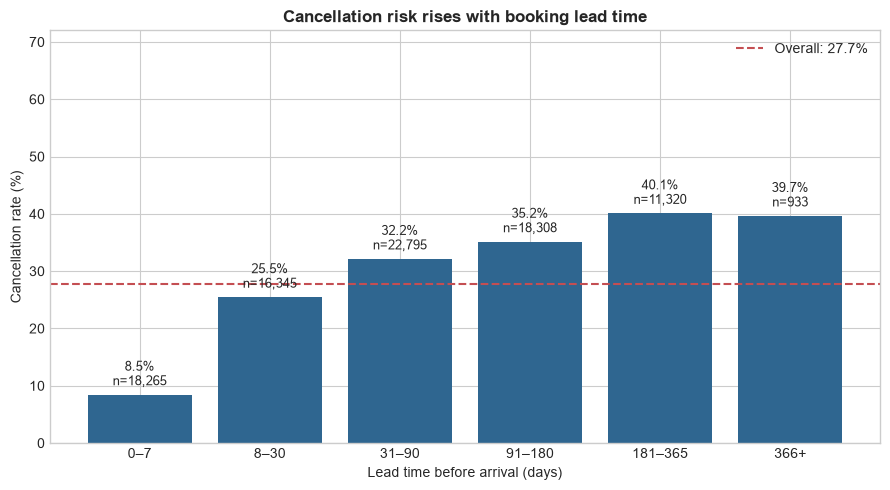

,cancellation_rate,bookings
lead_time_band,,
0–7,0.084588,18265
8–30,0.254818,16345
31–90,0.321649,22795
91–180,0.351595,18308
181–365,0.401148,11320
366+,0.396570,933


In [53]:
lead_edges = [-1, 7, 30, 90, 180, 365, np.inf]
lead_labels = ['0–7', '8–30', '31–90', '91–180', '181–365', '366+']
eda_df['lead_time_band'] = pd.cut(eda_df['lead_time'], bins=lead_edges, labels=lead_labels)
lead_summary = (eda_df.groupby('lead_time_band', observed=False)['is_canceled']
                .agg(cancellation_rate='mean', bookings='size'))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(lead_summary.index.astype(str), lead_summary['cancellation_rate'] * 100,
              color='#2F6690')
ax.axhline(overall_rate * 100, color='#C44E52', linestyle='--', linewidth=1.5,
           label=f'Overall: {overall_rate:.1%}')
ax.set(title='Cancellation risk rises with booking lead time',
       xlabel='Lead time before arrival (days)', ylabel='Cancellation rate (%)')
ax.set_ylim(0, 72)
ax.legend(frameon=False)
for bar, rate, n in zip(bars, lead_summary['cancellation_rate'], lead_summary['bookings']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.1%}\nn={n:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
lead_summary


**Decision-relevant interpretation.** The chart tests whether cancellation risk increases across progressively longer lead-time bands. Bands with higher rates are reasonable candidates for staged reconfirmation, but the displayed sample sizes should also be considered. This is an association, not evidence that lead time causes cancellation; market segment, deposit rules, and season may partly explain the pattern.


### 4.3 Grouped categorical analysis: market segment

**Purpose.** Identify channels or customer groups where targeted policies could have the greatest operational value. Only segments with at least 100 bookings are displayed so that very small, unstable categories do not drive decisions.


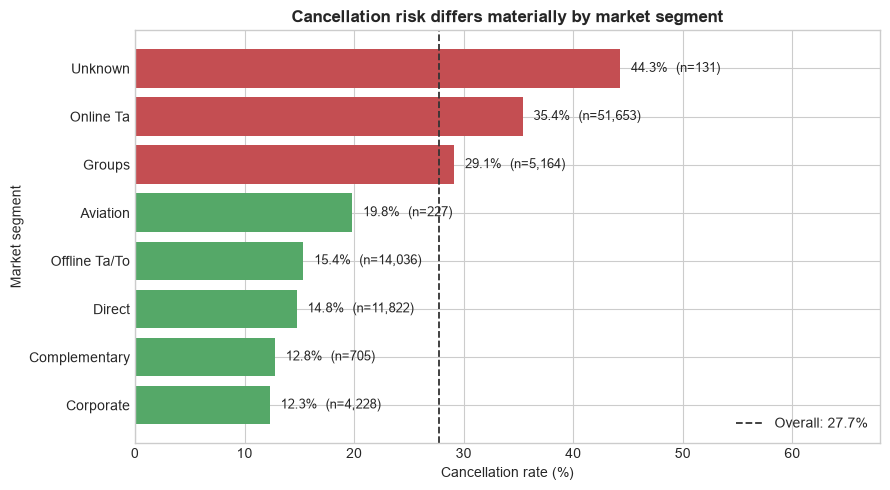

,cancellation_rate,bookings
market_segment_clean,,
Unknown,0.442748,131
Online Ta,0.353745,51653
Groups,0.291247,5164
Aviation,0.198238,227
Offline Ta/To,0.153676,14036
Direct,0.147522,11822
Complementary,0.127660,705
Corporate,0.122990,4228


In [54]:
segment_summary = (eda_df.groupby('market_segment_clean', dropna=False)['is_canceled']
                   .agg(cancellation_rate='mean', bookings='size')
                   .query('bookings >= 100')
                   .sort_values('cancellation_rate'))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C44E52' if x > overall_rate else '#55A868'
          for x in segment_summary['cancellation_rate']]
segment_labels = [str(value) if pd.notna(value) else 'Missing'
                  for value in segment_summary.index.tolist()]
bars = ax.barh(segment_labels, segment_summary['cancellation_rate'].to_numpy() * 100,
               color=colors)
ax.axvline(overall_rate * 100, color='#333333', linestyle='--', linewidth=1.3,
           label=f'Overall: {overall_rate:.1%}')
ax.set(title='Cancellation risk differs materially by market segment',
       xlabel='Cancellation rate (%)', ylabel='Market segment')
ax.set_xlim(0, 68)
ax.legend(frameon=False, loc='lower right')
for bar, rate, n in zip(bars, segment_summary['cancellation_rate'], segment_summary['bookings']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{rate:.1%}  (n={n:,})', va='center', fontsize=9)
plt.tight_layout()
plt.show()
segment_summary.sort_values('cancellation_rate', ascending=False)


**Decision-relevant interpretation.** The chart compares cancellation rates across market segments after excluding groups with fewer than 100 cleaned bookings. Segments that combine an above-average rate with a large sample are the most operationally relevant candidates for reviewing allotment release dates, deposits, or reconfirmation processes. A blanket restriction is not justified because segment may proxy for lead time, deposit type, or distribution channel.


### 4.4 Behavioural signal: special requests

**Purpose.** Examine whether observable booking engagement is associated with lower cancellation risk. Special requests are useful only if recorded before the risk score is generated.


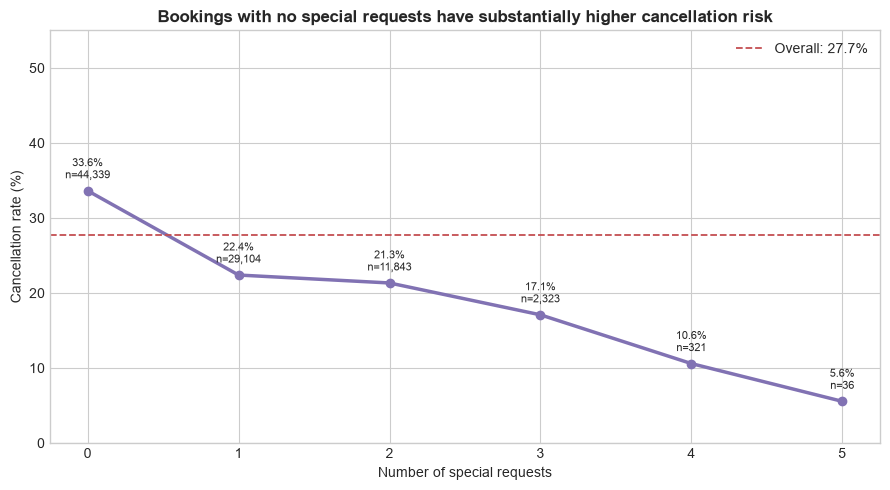

,cancellation_rate,bookings
total_of_special_requests,,
0,0.336318,44339
1,0.223955,29104
2,0.213375,11843
3,0.170900,2323
4,0.105919,321
5,0.055556,36


In [55]:
request_summary = (eda_df.groupby('total_of_special_requests')['is_canceled']
                   .agg(cancellation_rate='mean', bookings='size'))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(request_summary.index, request_summary['cancellation_rate'] * 100,
        marker='o', linewidth=2.5, color='#8172B3')
ax.axhline(overall_rate * 100, color='#C44E52', linestyle='--', linewidth=1.3,
           label=f'Overall: {overall_rate:.1%}')
ax.set(title='Bookings with no special requests have substantially higher cancellation risk',
       xlabel='Number of special requests', ylabel='Cancellation rate (%)', xticks=request_summary.index)
ax.set_ylim(0, 55)
ax.legend(frameon=False)
for x, row in request_summary.iterrows():
    ax.annotate(f"{row['cancellation_rate']:.1%}\nn={int(row['bookings']):,}",
                (x, row['cancellation_rate'] * 100), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.show()
request_summary


**Decision-relevant interpretation.** The chart assesses whether the number of special requests is associated with cancellation risk. Categories with small displayed sample sizes should not be treated as precise. Before modelling, the team must confirm when requests are entered or updated; a request recorded after the scoring time would create temporal leakage.


### 4.5 Temporal analysis: arrival month

**Purpose.** Determine whether cancellation risk changes over calendar time, which affects both operational staffing and how Assignment 2 should validate a model.


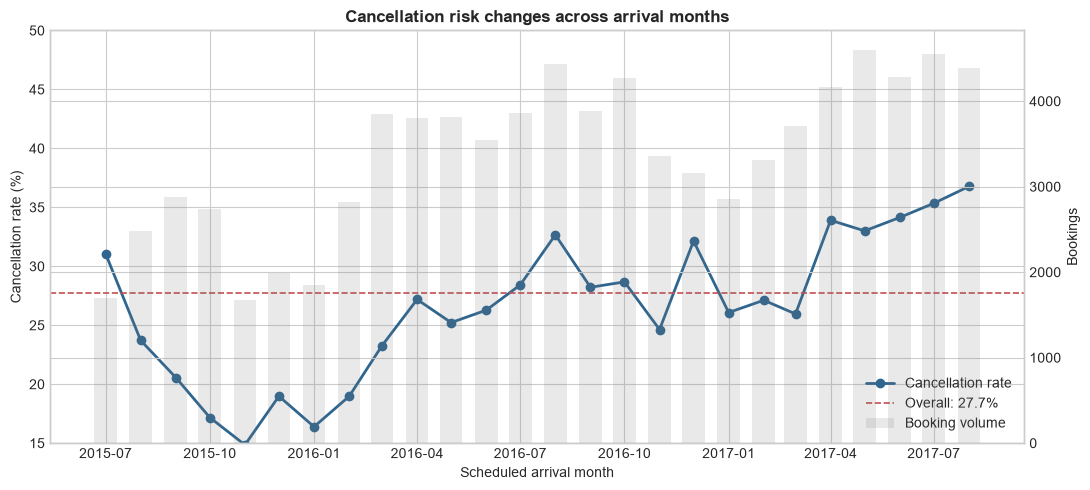

,cancellation_rate,bookings,cancellation_rate_pct
arrival_period,,,
2015-07-01,0.31,1693,31.07
2015-08-01,0.24,2476,23.71
2015-09-01,0.21,2874,20.56
2015-10-01,0.17,2743,17.17
2015-11-01,0.15,1670,14.85
2015-12-01,0.19,1992,18.98
2016-01-01,0.16,1855,16.39
2016-02-01,0.19,2826,18.97
2016-03-01,0.23,3847,23.26


In [56]:
month_number = {m: i for i, m in enumerate(
    ['January','February','March','April','May','June','July','August',
     'September','October','November','December'], start=1)}
eda_df['arrival_month_num'] = eda_df['arrival_date_month'].map(month_number)
eda_df['arrival_period'] = pd.to_datetime(dict(
    year=eda_df['arrival_date_year'], month=eda_df['arrival_month_num'], day=1))
monthly = (eda_df.groupby('arrival_period')['is_canceled']
           .agg(cancellation_rate='mean', bookings='size').sort_index())

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(monthly.index, monthly['cancellation_rate'] * 100, marker='o',
         color='#2F6690', linewidth=2, label='Cancellation rate')
ax1.axhline(overall_rate * 100, color='#C44E52', linestyle='--', linewidth=1.2,
            label=f'Overall: {overall_rate:.1%}')
ax1.set(title='Cancellation risk changes across arrival months',
        xlabel='Scheduled arrival month', ylabel='Cancellation rate (%)')
ax1.set_ylim(15, 50)
ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly['bookings'], width=20, alpha=0.16, color='#777777',
        label='Booking volume')
ax2.set_ylabel('Bookings')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='lower right')
plt.tight_layout()
plt.show()
monthly.assign(cancellation_rate_pct=monthly['cancellation_rate'] * 100).round(2)


**Decision-relevant interpretation.** The monthly series shows whether cancellation risk and booking volume change across the observed period. This variation matters when setting intervention capacity or overbooking limits. For Assignment 2, a chronological train/validation/test split is more credible than a purely random split because the model must generalise to later bookings. The dataset covers only a limited period, so apparent seasonality is not cleanly separated from year-to-year change.


### 4.6 Assignment 2 plan

**Key findings and hypotheses.** The EDA identifies long lead time, the Groups segment, absence of special requests and arrival period as strong risk indicators. These are associations and may interact: for example, group bookings may also be made further ahead. A notable additional hypothesis is that deposit type may reflect existing hotel risk policies rather than a simple causal protection against cancellation, so its meaning and timing require investigation.

**Proposed target and unit.** Predict the binary target `is_canceled` for each individual booking at a clearly defined pre-arrival scoring time. `reservation_status` and `reservation_status_date` must be excluded because they reveal the outcome.

**Candidate features.** Begin with variables known by the scoring time: `lead_time`, hotel type, arrival calendar variables, length of stay, adults/children/babies, meal, country, market segment, distribution channel, repeated-guest status, previous cancellations and completed bookings, reserved room type, deposit type, customer type, ADR, parking requirement and special requests. Use `assigned_room_type`, `booking_changes`, agent/company identifiers and waiting-list information only after verifying that each is available at the intended scoring time. High-cardinality identifiers should be grouped, encoded carefully or omitted.

**Data preparation.** Resolve whether exact duplicates represent separate bookings before removing them; standardise case, spacing and spelling in categorical variables; handle missingness explicitly (especially `company` at 94.3% and `agent` at 13.8%); investigate impossible or extreme values such as non-positive guest counts and ADR outliers; and preserve a reproducible cleaning pipeline fitted only on training data.

**Suitable modelling directions (Assignment 2 only).** Establish an interpretable regularised logistic-regression baseline, then compare it with a tree-based method capable of nonlinearities and interactions (for example, random forest or gradient boosting). Use time-ordered validation, probability calibration, and metrics aligned with intervention decisions: PR-AUC/ROC-AUC for ranking, recall and precision at a selected threshold, calibration, and an estimated cost matrix for false positives and false negatives. Model training and comparison are deliberately not performed in Assignment 1.

**Important risks and tests.** Prevent target and temporal leakage; test performance separately by hotel, time period and major market segment; assess whether category effects remain after controlling for lead time and deposit type; check probability drift over time; and conduct threshold sensitivity analysis based on contact capacity and intervention cost. Predictions should support human decisions rather than justify blanket restrictions on customer groups.


## 5. Team contribution and Week 6 checkpoint

| Team member | Primary responsibility | 
|---|---|
| Sia | Parts 1 and 3; Github repository; Report Structure|
| Yanjun Zhu | Parts 2 and 4; reproducibility review and README | 




# COMP5310 Assignment 2

## 1. Scope and Evaluation Contract

### 1.1 Stage 1 feedback response and scope lock

The Stage 1 evidence **confirmed** the selected problem: cancellation is common enough to matter operationally, varies across booking characteristics, and should be treated as a booking-level prediction problem. Stage 1 also confirmed that `reservation_status` and `reservation_status_date` reveal the eventual outcome and must not be predictors. The project scope remains focused on supporting targeted, low-cost cancellation-management actions rather than automatically refusing bookings or applying blanket restrictions to customer groups.

### 1.2 Decision contract

| Contract item | Pre-declared definition |
|---|---|
| Primary stakeholder | Hotel revenue or reservations manager |
| Decision supported | Which upcoming bookings should be prioritised for a low-cost intervention, such as a confirmation reminder, manual review, or deposit-policy review |
| Target | `is_canceled`: 1 if the booking is ultimately cancelled and 0 otherwise |
| Unit of prediction | One reservation record |
| Decision time | Immediately after the booking is created, using only information recorded by that point |
| Prediction horizon | From booking creation to the scheduled arrival date; this varies by booking and is represented partly by `lead_time` |
| Model output | A cancellation probability used to rank bookings; an action threshold will be selected later using validation data and operational capacity |

The prediction is decision support, not an automatic adverse decision. High-risk bookings should receive proportionate interventions, and the final threshold must be chosen without using the held-out test set.

### 1.3 Consequences of errors

- A **false positive** occurs when a booking is flagged as likely to cancel but is honoured. The hotel may spend staff time or communication cost unnecessarily, and repeated or intrusive contact could inconvenience a reliable customer. It would be especially harmful if a false positive led to an excessive deposit or overbooking response.
- A **false negative** occurs when a booking is predicted as low risk but is cancelled. The hotel loses an opportunity to reconfirm the booking, adjust inventory, or resell the room. Because room-night inventory expires, a late cancellation may create unrecoverable revenue loss.
- **Overprediction** produces too many high probabilities. It can overwhelm intervention capacity and reduce trust in the model.
- **Underprediction** hides genuine cancellation exposure and may leave occupancy and revenue forecasts too optimistic.

For the proposed low-cost interventions, missing a cancellation is expected to be more costly than sending one unnecessary reminder. However, this assumption must be checked with the stakeholder before a threshold or monetary cost matrix is finalised.

### 1.4 Pre-declared evaluation metrics

The **primary model-comparison metric is area under the precision-recall curve (PR-AUC / average precision)**, with cancellation (`is_canceled = 1`) as the positive class. PR-AUC measures how well a model ranks actual cancellations while showing the trade-off between finding more cancellations and spending intervention capacity on false alarms. It is more directly connected to the positive class and targeted intervention than overall accuracy, which can look acceptable by predicting the more common non-cancellation class.

Secondary metrics are recall, precision and F2-score at a validation-selected operating threshold; ROC-AUC for overall ranking; and Brier score plus calibration plots for probability quality. Recall reflects missed risky bookings, precision reflects wasted interventions, and F2 gives recall more weight under the current cost assumption. The final report should also show a confusion matrix and the number of interventions per 1,000 bookings. Accuracy may be reported for transparency but will not select the model.


## 2. Baseline and Experimental Design

### 2.1 Data handover and design rules

The chronological split uses scheduled arrival date because the dataset has no reliable booking-creation timestamp. This is an approximation: `lead_time` implies creation timing, but reconstructing a date from it may add uncertainty. The earliest 60% of arrival dates form training data, the next 20% form validation data, and the latest 20% form the final test data. Entire arrival dates stay in one partition. Validation data will support model and threshold selection; the test data remain untouched until the final comparison.


In [57]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

TARGET = "is_canceled"

# Convert month names into month numbers
month_number = {
    month: number
    for number, month in enumerate(
        [
            "January",
            "February",
            "March",
            "April",
            "May",
            "June",
            "July",
            "August",
            "September",
            "October",
            "November",
            "December",
        ],
        start=1,
    )
}

# Create a complete arrival date
hotel_bookings_cleaned["arrival_month_number"] = (
    hotel_bookings_cleaned["arrival_date_month"].map(month_number)
)

hotel_bookings_cleaned["arrival_date"] = pd.to_datetime(
    {
        "year": hotel_bookings_cleaned["arrival_date_year"],
        "month": hotel_bookings_cleaned["arrival_month_number"],
        "day": hotel_bookings_cleaned["arrival_date_day_of_month"],
    },
    errors="coerce",
)

# Sort all unique arrival dates
unique_dates = np.array(
    sorted(hotel_bookings_cleaned["arrival_date"].dropna().unique())
)

# Use the first 60% of dates for training
train_boundary = unique_dates[
    int(len(unique_dates) * 0.60) - 1
]

# Use the following 20% of dates for validation
validation_boundary = unique_dates[
    int(len(unique_dates) * 0.80) - 1
]

# Define which rows belong to each dataset
train_mask = (
    hotel_bookings_cleaned["arrival_date"]
    <= train_boundary
)

validation_mask = (
    (hotel_bookings_cleaned["arrival_date"] > train_boundary)
    & (
        hotel_bookings_cleaned["arrival_date"]
        <= validation_boundary
    )
)

test_mask = (
    hotel_bookings_cleaned["arrival_date"]
    > validation_boundary
)

# Create the three datasets
train_df = hotel_bookings_cleaned.loc[train_mask].copy()

validation_df = hotel_bookings_cleaned.loc[
    validation_mask
].copy()

test_df = hotel_bookings_cleaned.loc[test_mask].copy()

# Summarise the data split
split_summary = pd.DataFrame(
    {
        "rows": [
            len(train_df),
            len(validation_df),
            len(test_df),
        ],
        "start_arrival": [
            train_df["arrival_date"].min(),
            validation_df["arrival_date"].min(),
            test_df["arrival_date"].min(),
        ],
        "end_arrival": [
            train_df["arrival_date"].max(),
            validation_df["arrival_date"].max(),
            test_df["arrival_date"].max(),
        ],
        "cancellation_rate": [
            train_df[TARGET].mean(),
            validation_df[TARGET].mean(),
            test_df[TARGET].mean(),
        ],
    },
    index=["train", "validation", "test"],
)

# Format cancellation rates as percentages
split_summary_display = split_summary.copy()

split_summary_display["cancellation_rate"] = (
    split_summary_display["cancellation_rate"]
    .map("{:.1%}".format)
)

display(split_summary_display)

,rows,start_arrival,end_arrival,cancellation_rate
train,47576,2015-07-01,2016-10-17,24.7%
validation,17663,2016-10-18,2017-03-25,27.5%
test,22727,2017-03-26,2017-08-31,34.3%


### 2.2 Transparent baseline

The baseline learns only the cancellation rate and majority class from the training partition. Its probability prediction is the training historical cancellation rate for every validation booking. Its class prediction is the training majority class. This deliberately simple reference establishes how much a candidate model improves on a policy that does not use booking characteristics.


In [58]:
y_train = train_df[TARGET].astype(int)
y_validation = validation_df[TARGET].astype(int)

training_cancellation_rate = float(y_train.mean())
training_majority_class = int(y_train.mode().iloc[0])

baseline_probability = np.full(len(y_validation), training_cancellation_rate)
baseline_class = np.full(len(y_validation), training_majority_class)

baseline_metrics = {
    "pr_auc": average_precision_score(y_validation, baseline_probability),
    "roc_auc": roc_auc_score(y_validation, baseline_probability),
    "brier_score": brier_score_loss(y_validation, baseline_probability),
    "accuracy": accuracy_score(y_validation, baseline_class),
    "precision": precision_score(y_validation, baseline_class, zero_division=0),
    "recall": recall_score(y_validation, baseline_class, zero_division=0),
    "f2": fbeta_score(y_validation, baseline_class, beta=2, zero_division=0),
}

baseline_results = pd.DataFrame([baseline_metrics], index=["Historical-rate / majority-class baseline"])
display(baseline_results.round(4))
print("Training cancellation rate:", f"{training_cancellation_rate:.1%}")
print("Training majority class:", training_majority_class)
print("Validation confusion matrix [[TN, FP], [FN, TP]]:")
display(pd.DataFrame(
    confusion_matrix(y_validation, baseline_class),
    index=["actual_0", "actual_1"],
    columns=["predicted_0", "predicted_1"],
))


,pr_auc,roc_auc,brier_score,accuracy,precision,recall,f2
Historical-rate / majority-class baseline,0.2754,0.5,0.2004,0.7246,0.0,0.0,0.0


Training cancellation rate: 24.7%
Training majority class: 0
Validation confusion matrix [[TN, FP], [FN, TP]]:


,predicted_0,predicted_1
actual_0,12798,0
actual_1,4865,0


The historical-rate and majority-class baseline was retained as the minimum benchmark. As expected, it identified no cancellations and therefore produced zero recall and F2 score. A logistic regression baseline was additionally established using a small set of variables available at booking time. This provides a stronger but still interpretable benchmark for evaluating whether more complex models produce meaningful improvements.

In [59]:
# Stronger baseline: Logistic Regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Only use information available when the booking decision is made
baseline_features = [
    "lead_time",
    "previous_cancellations",
    "booking_changes",
    "total_of_special_requests",
    "deposit_type",
    "customer_type",
    "market_segment",
]

numeric_features = [
    "lead_time",
    "previous_cancellations",
    "booking_changes",
    "total_of_special_requests",
]

categorical_features = [
    "deposit_type",
    "customer_type",
    "market_segment",
]

X_train_baseline = train_df[baseline_features]
y_train_baseline = train_df[TARGET]

X_validation_baseline = validation_df[baseline_features]
y_validation_baseline = validation_df[TARGET]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
            ),
        ),
    ]
)

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

logistic_baseline = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=5310,
            ),
        ),
    ]
)

# Fit transformations and model using training data only
logistic_baseline.fit(X_train_baseline, y_train_baseline)

# Generate validation predictions
validation_probability = logistic_baseline.predict_proba(
    X_validation_baseline
)[:, 1]

validation_prediction = (
    validation_probability >= 0.5
).astype(int)

logistic_baseline_results = pd.DataFrame(
    {
        "pr_auc": [
            average_precision_score(
                y_validation_baseline,
                validation_probability,
            )
        ],
        "roc_auc": [
            roc_auc_score(
                y_validation_baseline,
                validation_probability,
            )
        ],
        "brier_score": [
            brier_score_loss(
                y_validation_baseline,
                validation_probability,
            )
        ],
        "accuracy": [
            accuracy_score(
                y_validation_baseline,
                validation_prediction,
            )
        ],
        "precision": [
            precision_score(
                y_validation_baseline,
                validation_prediction,
                zero_division=0,
            )
        ],
        "recall": [
            recall_score(
                y_validation_baseline,
                validation_prediction,
                zero_division=0,
            )
        ],
        "f2": [
            fbeta_score(
                y_validation_baseline,
                validation_prediction,
                beta=2,
                zero_division=0,
            )
        ],
    },
    index=["Logistic Regression baseline"],
)

display(logistic_baseline_results)

logistic_confusion_matrix = confusion_matrix(
    y_validation_baseline,
    validation_prediction,
)

display(
    pd.DataFrame(
        logistic_confusion_matrix,
        index=["actual_0", "actual_1"],
        columns=["predicted_0", "predicted_1"],
    )
)

,pr_auc,roc_auc,brier_score,accuracy,precision,recall,f2
Logistic Regression baseline,0.55778,0.741819,0.200877,0.691672,0.459056,0.669476,0.613256


,predicted_0,predicted_1
actual_0,8960,3838
actual_1,1608,3257


### 2.3 Preprocessing, features, imbalance and leakage controls

The candidate feature set is restricted to fields expected to exist at initial booking time. The following are excluded before modelling:

- `is_canceled` (the target), `reservation_status`, and `reservation_status_date` (direct outcome leakage);
- `assigned_room_type`, `booking_changes`, and `days_in_waiting_list` (may be created or updated after booking);
- `company` and `agent` (high missingness and/or high-cardinality identifiers whose operational meaning is uncertain);
- the temporary split fields created above.

Numeric missing values will be median-imputed and standardised; categorical missing values will be most-frequent-imputed and one-hot encoded with unseen validation/test categories ignored. These fitted operations belong inside a pipeline and will be learned only from the training partition. The initial candidates use `class_weight="balanced"` where supported rather than resampling. If resampling is later tested, it must occur inside each training fold only. The natural class distribution is preserved in validation and test sets.

Arrival year, month and day are retained as calendar features, while length of stay is derived deterministically from the two stay-night columns. This feature engineering uses no target information. All stochastic models and splitters must use seed 5310. The final test set cannot be used for feature selection, hyperparameter tuning, threshold selection, or probability calibration.


In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "lead_time", "arrival_date_year", "arrival_date_week_number",
    "arrival_date_day_of_month", "stays_in_weekend_nights",
    "stays_in_week_nights", "adults", "children", "babies",
    "is_repeated_guest", "previous_cancellations",
    "previous_bookings_not_canceled", "adr",
    "required_car_parking_spaces", "total_of_special_requests",
]
categorical_features = [
    "hotel", "arrival_date_month", "meal", "country", "market_segment",
    "distribution_channel", "reserved_room_type", "deposit_type", "customer_type",
]

model_features = numeric_features + categorical_features
missing_features = sorted(set(model_features).difference(train_df.columns))
if missing_features:
    raise KeyError(f"Expected model features are missing: {missing_features}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

# These objects are declared but deliberately not fitted in Parts 1-2.
X_train = train_df[model_features].copy()
X_validation = validation_df[model_features].copy()
X_test = test_df[model_features].copy()
y_test = test_df[TARGET].astype(int)

print(f"Declared {len(model_features)} pre-booking features.")
print("Preprocessor fitted:", hasattr(preprocessor, "transformers_"))


Declared 24 pre-booking features.
Preprocessor fitted: False


### 2.4 Experiment log

Every reported result must be added to the log with a unique ID, data version, chronological split, feature set, preprocessing, imbalance treatment, seed, threshold rule and metrics. Candidate models should append rows rather than overwrite earlier experiments. The test-set metric fields remain empty until the final locked evaluation.


In [62]:
experiment_log_columns = [
    "experiment_id", "timestamp_utc", "model", "data_source", "data_rows",
    "split_strategy", "train_end", "validation_end", "features",
    "preprocessing", "imbalance_handling", "random_seed", "threshold_rule",
    "evaluation_partition", "pr_auc", "roc_auc", "brier_score", "accuracy",
    "precision", "recall", "f2", "notes",
]

experiment_log = pd.DataFrame([
    {
        "experiment_id": "EXP-000-BASELINE",
        "timestamp_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "model": "training historical rate / training majority class",
        "data_source": "hotel_bookings_cleaned (Assignment 1 in-memory output)",
        "data_rows": len(hotel_bookings_cleaned),
        "split_strategy": "chronological 60/20/20 by unique scheduled-arrival date",
        "train_end": str(pd.Timestamp(train_boundary).date()),
        "validation_end": str(pd.Timestamp(validation_boundary).date()),
        "features": "none",
        "preprocessing": "none",
        "imbalance_handling": "none; natural validation prevalence retained",
        "random_seed": 5310,
        "threshold_rule": f"training majority class = {training_majority_class}",
        "evaluation_partition": "validation",
        **baseline_metrics,
        "notes": "Probability baseline equals the training cancellation rate; final test untouched.",
    }
], columns=experiment_log_columns)

experiment_log_path = OUTPUT_DIR / "assignment2_experiment_log.csv"
experiment_log.to_csv(experiment_log_path, index=False)
display(experiment_log)
print("Experiment log saved to:", experiment_log_path.relative_to(PROJECT_ROOT))


,experiment_id,timestamp_utc,model,data_source,data_rows,split_strategy,train_end,validation_end,features,preprocessing,imbalance_handling,random_seed,threshold_rule,evaluation_partition,pr_auc,roc_auc,brier_score,accuracy,precision,recall,f2,notes
0,EXP-000-BASELINE,2026-09-28T12:20:03.472147+00:00,training historical rate / training majority c...,hotel_bookings_cleaned (Assignment 1 in-memory...,87966,chronological 60/20/20 by unique scheduled-arr...,2016-10-17,2017-03-25,none,none,none; natural validation prevalence retained,5310,training majority class = 0,validation,0.275435,0.5,0.2004,0.724565,0.0,0.0,0.0,Probability baseline equals the training cance...


Experiment log saved to: outputs/assignment2_experiment_log.csv


### 2.5 Controls locked before candidate modelling

1. Fit preprocessing and models only on `train_df`; use `validation_df` for model, hyperparameter and threshold choices.
2. Keep `test_df` sealed until the complete modelling procedure is fixed.
3. Compare the baseline and both candidate models on the same partitions and metrics.
4. Use probability scores, not hard labels, for PR-AUC, ROC-AUC and Brier score.
5. Check temporal stability and report metrics by hotel and major market segment after the primary comparison.
6. Record every run in `experiment_log`; do not report an unlogged result.
7. If the decision time changes from initial booking, revise the feature-availability audit before modelling.
